In [8]:
import os, joblib, gc, numpy as np, pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Konfigurasi Global
dataset_path = "/content/drive/MyDrive/Colab Notebooks"
LATENT_DIM = 16
RANDOM_STATE = 42

# 1. Custom Layer untuk VAE
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch, dim = tf.shape(z_mean)[0], tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# 2. Custom Model VAE
class VAE(models.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder, self.decoder = encoder, decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            recon_loss = tf.reduce_mean(tf.keras.losses.mse(data, reconstruction))
            kl_loss = -0.5 * tf.reduce_mean(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            total_loss = recon_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        return {"loss": self.total_loss_tracker.result()}

In [18]:
def load_and_filter_data():
    print("Memuat dan memfilter data...")
    data = joblib.load(os.path.join(dataset_path, "dataset_split.joblib"))
    toxic = [
        'Pkt Len Var', 'Bwd IAT Mean', 'Down/Up Ratio', 'ACK Flag Cnt',
        'Bwd Pkt Len Min', 'Active Mean', 'Fwd Pkt Len Min', 'Pkt Len Min',
        'Fwd URG Flags', 'Active Min', 'Active Std', 'Active Max',
        'Idle Std', 'SYN Flag Cnt'
    ]
    feat_names = data['features']
    h_idx = [i for i, f in enumerate(feat_names) if f not in toxic]

    # Ambil data (X) dan Label (y)
    X_train = data['X_train'][:, h_idx].astype('float32')
    X_val   = data['X_val'][:, h_idx].astype('float32')
    X_test  = data['X_test'][:, h_idx].astype('float32')
    y_train, y_val, y_test = data['y_train'], data['y_val'], data['y_test']

    del data
    gc.collect()
    return X_train, X_val, X_test, y_train, y_val, y_test

X_train, X_val, X_test, y_train, y_val, y_test = load_and_filter_data()

Memuat dan memfilter data...


In [3]:
input_dim = X_train.shape[1]
encoder_inputs = layers.Input(shape=(input_dim,))
h = layers.Dense(64, activation="relu")(encoder_inputs)
z_mean = layers.Dense(LATENT_DIM, name="z_mean")(h)
z_log_var = layers.Dense(LATENT_DIM, name="z_log_var")(h)
z = Sampling()([z_mean, z_log_var])
encoder = models.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

decoder_inputs = layers.Input(shape=(LATENT_DIM,))
h_dec = layers.Dense(64, activation="relu")(decoder_inputs)
decoder_outputs = layers.Dense(input_dim, activation="sigmoid")(h_dec)
decoder = models.Model(decoder_inputs, decoder_outputs, name="decoder")

vae = VAE(encoder, decoder)
vae.compile(optimizer=tf.keras.optimizers.Adam(1e-3))

X_benign = X_train[y_train == 0]
vae.fit(X_benign, epochs=30, batch_size=1024)
encoder.save(os.path.join(dataset_path, "vae_encoder.keras"))

Epoch 1/30
9154/9154 ━━━━━━━━━━━━━━━━━━━━ 54s 6ms/step - loss: 0.0836
Epoch 2/30
9154/9154 ━━━━━━━━━━━━━━━━━━━━ 51s 5ms/step - loss: 0.0825
Epoch 3/30
9154/9154 ━━━━━━━━━━━━━━━━━━━━ 52s 6ms/step - loss: 0.0825
Epoch 4/30
9154/9154 ━━━━━━━━━━━━━━━━━━━━ 51s 5ms/step - loss: 0.0825
Epoch 5/30
9154/9154 ━━━━━━━━━━━━━━━━━━━━ 52s 6ms/step - loss: 0.0825
Epoch 6/30
9154/9154 ━━━━━━━━━━━━━━━━━━━━ 80s 5ms/step - loss: 0.0825
Epoch 7/30
9154/9154 ━━━━━━━━━━━━━━━━━━━━ 52s 6ms/step - loss: 0.0825
Epoch 8/30
9154/9154 ━━━━━━━━━━━━━━━━━━━━ 50s 5ms/step - loss: 0.0825
Epoch 9/30
9154/9154 ━━━━━━━━━━━━━━━━━━━━ 52s 6ms/step - loss: 0.0825
Epoch 10/30
9154/9154 ━━━━━━━━━━━━━━━━━━━━ 52s 6ms/step - loss: 0.0825
Epoch 11/30
9154/9154 ━━━━━━━━━━━━━━━━━━━━ 53s 6ms/step - loss: 0.0824
Epoch 12/30
9154/9154 ━━━━━━━━━━━━━━━━━━━━ 52s 6ms/step - loss: 0.0825
Epoch 13/30
9154/9154 ━━━━━━━━━━━━━━━━━━━━ 81s 6ms/step - loss: 0.0825
Epoch 14/30
9154/9154 ━━━━━━━━━━━━━━━━━━━━ 53s 6ms/step - loss: 0.0825
Epoch 15/30
915

In [3]:
import os
from google.colab import drive

if not os.path.exists("/content/drive"):
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

dataset_path = "/content/drive/MyDrive/Colab Notebooks"

if os.path.exists(dataset_path):
    print(f"Folder ditemukan: {dataset_path}")
else:
    print("Folder tidak ditemukan.")

Folder ditemukan: /content/drive/MyDrive/Colab Notebooks


In [5]:
import tensorflow as tf
from tensorflow.keras import layers

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [6]:
import os
import tensorflow as tf

encoder_path = os.path.join(dataset_path, "vae_encoder.keras")

if os.path.exists(encoder_path):
    print("Memuat Encoder dari Drive...")
    encoder = tf.keras.models.load_model(
        encoder_path,
        custom_objects={'Sampling': Sampling}
    )
else:
    print("File tidak ditemukan.")

Memuat Encoder dari Drive...


In [10]:
import gc
import numpy as np

# --- 1. Proses Z_train ---
print("Mengekstrak Z_train...")
Z_train, _, _ = encoder.predict(X_train, batch_size=2048)
del X_train
gc.collect()
print("Z_train selesai.")

# --- 2. Proses Z_val ---
print("Mengekstrak Z_val...")
Z_val, _, _ = encoder.predict(X_val, batch_size=2048)
del X_val
gc.collect()
print("Z_val selesai.")

# --- 3. Proses Z_test ---
print("Mengekstrak Z_test...")
Z_test, _, _ = encoder.predict(X_test, batch_size=2048)
del X_test
gc.collect()
print("Z_test selesai.")

Mengekstrak Z_train...
5516/5516 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step
Z_train selesai.
Mengekstrak Z_val...
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
Z_val selesai.
Mengekstrak Z_test...
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step
Z_test selesai.


In [11]:
classifier = models.Sequential([
    layers.Input(shape=(LATENT_DIM,)),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

classifier.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                   loss='binary_crossentropy',
                   metrics=[tf.keras.metrics.AUC(name='auc')])

cw = {0: 1.0, 1: 2.5}

history = classifier.fit(
    Z_train, y_train,
    epochs=30, batch_size=1024,
    validation_data=(Z_val, y_val),
    class_weight=cw,
    callbacks=[callbacks.EarlyStopping(monitor='val_auc', patience=5, restore_best_weights=True, mode='max')],
    verbose=1
)

Epoch 1/30
11032/11032 ━━━━━━━━━━━━━━━━━━━━ 190s 17ms/step - auc: 0.9063 - loss: 0.4730 - val_auc: 0.9443 - val_loss: 0.2180
Epoch 2/30
11032/11032 ━━━━━━━━━━━━━━━━━━━━ 198s 18ms/step - auc: 0.9523 - loss: 0.3067 - val_auc: 0.9648 - val_loss: 0.1587
Epoch 3/30
11032/11032 ━━━━━━━━━━━━━━━━━━━━ 186s 17ms/step - auc: 0.9645 - loss: 0.2536 - val_auc: 0.9706 - val_loss: 0.1354
Epoch 4/30
11032/11032 ━━━━━━━━━━━━━━━━━━━━ 185s 17ms/step - auc: 0.9682 - loss: 0.2309 - val_auc: 0.9726 - val_loss: 0.1326
Epoch 5/30
11032/11032 ━━━━━━━━━━━━━━━━━━━━ 201s 17ms/step - auc: 0.9700 - loss: 0.2171 - val_auc: 0.9740 - val_loss: 0.1127
Epoch 6/30
11032/11032 ━━━━━━━━━━━━━━━━━━━━ 186s 17ms/step - auc: 0.9714 - loss: 0.2056 - val_auc: 0.9745 - val_loss: 0.1098
Epoch 7/30
11032/11032 ━━━━━━━━━━━━━━━━━━━━ 183s 17ms/step - auc: 0.9724 - loss: 0.1969 - val_auc: 0.9750 - val_loss: 0.1015
Epoch 8/30
11032/11032 ━━━━━━━━━━━━━━━━━━━━ 185s 17ms/step - auc: 0.9734 - loss: 0.1885 - val_auc: 0.9761 - val_loss: 0.1035


In [12]:
y_probs = classifier.predict(Z_test, batch_size=2048).ravel()
results = []

for t in np.linspace(0.1, 0.9, 81):
    y_pred = (y_probs > t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    fpr = (fp / (fp + tn)) * 100
    f1 = f1_score(y_test, y_pred)
    results.append((t, f1, fpr))

valid = [r for r in results if r[2] <= 2.0 and r[1] >= 0.85]
if valid:
    best = max(valid, key=lambda x: x[1])
    print(f"Optimal Threshold: {best[0]:.4f} | F1: {best[1]*100:.2f}% | FPR: {best[2]:.2f}%")
else:
    print("Kriteria belum tercapai.")

1182/1182 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step
Optimal Threshold: 0.5800 | F1: 95.09% | FPR: 0.61%



VAE Classifier
                   precision    recall  f1-score   support

  Normal (Benign)     0.9864    0.9939    0.9901   2008536
Serangan (Attack)     0.9690    0.9334    0.9509    412040

         accuracy                         0.9836   2420576
        macro avg     0.9777    0.9637    0.9705   2420576
     weighted avg     0.9835    0.9836    0.9835   2420576

------------------------------------------------------------
FPR : 0.6127%
F1-SCORE (Attack): 95.09%


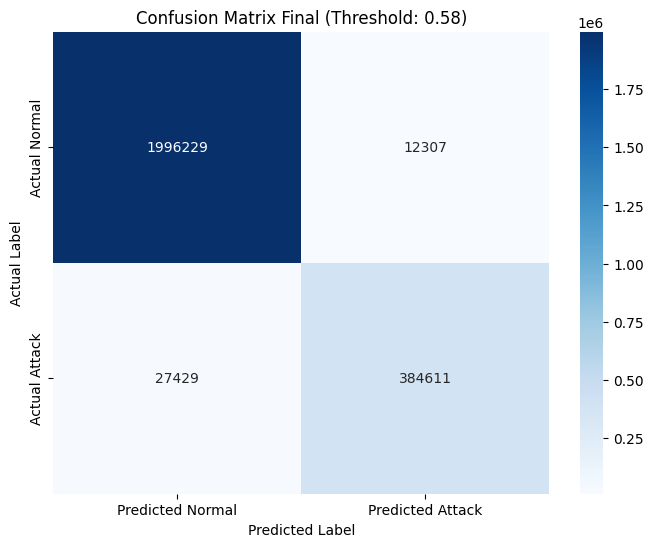

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

opt_threshold = 0.5800
y_pred_final = (y_probs > opt_threshold).astype(int)

print("\n" + "="*60)
print("VAE Classifier")
print("="*60)
report = classification_report(y_test, y_pred_final,
                               target_names=['Normal (Benign)', 'Serangan (Attack)'],
                               digits=4)
print(report)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()
fpr_final = (fp / (fp + tn)) * 100
print("-" * 60)
print(f"FPR : {fpr_final:.4f}%")
print(f"F1-SCORE (Attack): {f1_score(y_test, y_pred_final)*100:.2f}%")
print("="*60)

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Normal', 'Predicted Attack'],
            yticklabels=['Actual Normal', 'Actual Attack'])

plt.title(f'Confusion Matrix Final (Threshold: {opt_threshold})')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

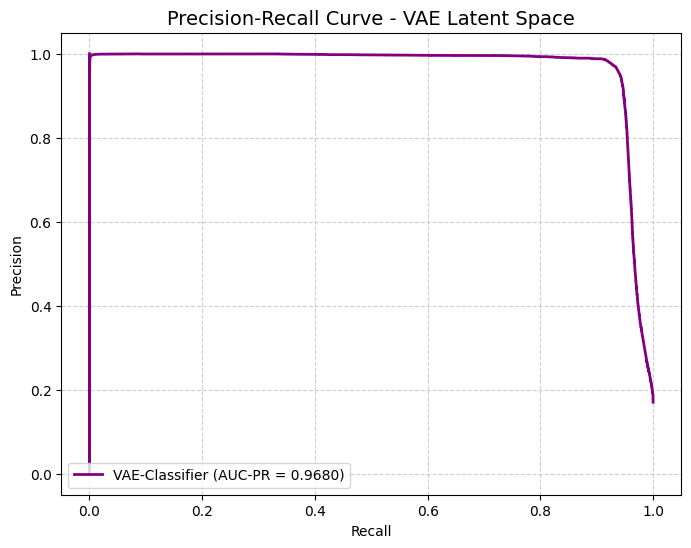

VAE Latent PR-AUC: 0.9680


In [14]:
from sklearn.metrics import precision_recall_curve, auc, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

precision, recall, thresholds_pr = precision_recall_curve(y_test, y_probs)
pr_auc_vae = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'VAE-Classifier (AUC-PR = {pr_auc_vae:.4f})', color='purple', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - VAE Latent Space', fontsize=14)
plt.legend(loc="lower left")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"VAE Latent PR-AUC: {pr_auc_vae:.4f}")

In [16]:
from sklearn.metrics import confusion_matrix, recall_score

y_pred_vae = (y_probs > 0.5800).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_vae).ravel()
fpr = fp / (fp + tn)
specificity = tn / (tn + fp)

print("="*40)
print(f"HASIL ANALISIS ERROR VAE-CLASSIFIER")
print("="*40)
print(f"True Negatives (TN)  : {tn:,}")
print(f"False Positives (FP) : {fp:,}")
print(f"False Negative (FN)  : {fn:,}")
print(f"True Positive (TP)   : {tp:,}")
print("-" * 40)
print(f"FPR (False Positive Rate) : {fpr:.6f} ({fpr*100:.4f}%)")
print(f"Specificity (TNR)         : {specificity:.6f} ({specificity*100:.4f}%)")
print("="*40)

recall_attack = recall_score(y_test, y_pred_vae)
print(f"Detection Rate Attack : {recall_attack*100:.2f}%")

HASIL ANALISIS ERROR VAE-CLASSIFIER
True Negatives (TN)  : 1,996,229
False Positives (FP) : 12,307
False Negative (FN)  : 27,429
True Positive (TP)   : 384,611
----------------------------------------
FPR (False Positive Rate) : 0.006127 (0.6127%)
Specificity (TNR)         : 0.993873 (99.3873%)
Detection Rate Attack : 93.34%


In [19]:
def predict_vae_live(data_point):

    input_data = data_point.reshape(1, -1).astype('float32')
    z_mean, _, _ = encoder.predict(input_data, verbose=0)
    prob = classifier.predict(z_mean, verbose=0)[0][0]

    if prob >= 0.5800:
        label = "ATTACK"
        confidence = prob
    else:
        label = "BENIGN"
        confidence = 1 - prob

    return label, confidence

idx = 100
hasil, skor = predict_vae_live(X_test[idx])
label_asli = "Attack" if y_test[idx] == 1 else "Benign"

print(f"--- UJI COBA TEST DATA KE-{idx} ---")
print(f"Label Asli      : {label_asli}")
print(f"Hasil AI VAE    : {hasil}")
print(f"Tingkat Yakin   : {skor*100:.2f}%")

--- UJI COBA TEST DATA KE-100 ---
Label Asli      : Attack
Hasil AI VAE    : ATTACK
Tingkat Yakin   : 93.55%


In [21]:
from sklearn.ensemble import IsolationForest
import numpy as np
import pandas as pd

print("Melatih Isolation Forest pada fitur laten Benign...")
Z_benign_train = Z_train[y_train == 0]

iso_vae = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=42,
    n_jobs=-1
)
iso_vae.fit(Z_benign_train)
print("Isolation Forest di Ruang Laten siap!")

def zero_day_detector_vae(raw_data_point, latent_data_point):
    prob = classifier.predict(latent_data_point.reshape(1, -1), verbose=0)[0][0]
    vae_label = "ATTACK" if prob >= 0.5800 else "BENIGN"
    is_normal = iso_vae.predict(latent_data_point.reshape(1, -1))[0]

    status = "Aman"
    if vae_label == "BENIGN" and is_normal == -1:
        status = "POTENSI ZERO-DAY (Anomaly Detected)"
    elif vae_label == "ATTACK":
        status = "SERANGAN TERDETEKSI (Known Attack)"
    else:
        status = "TRAFIK NORMAL"

    return status, prob, is_normal

idx = 100
hasil_sim, p_score_sim, anomaly_score_sim = zero_day_detector_vae(None, Z_test[idx])

print(f"\n--- HASIL ANALISIS DATA KE-{idx} ---")
print(f"Status Akhir   : {hasil_sim}")
print(f"VAE Prob       : {p_score_sim:.4f}")
print(f"Anomaly Laten  : {'Outlier' if anomaly_score_sim == -1 else 'Normal'}")

print("\nMenyisir celah keamanan pada VAE-Classifier...")

y_pred_vae_idx = (y_probs > 0.5800).astype(int)
missed_by_vae = np.where((y_test == 1) & (y_pred_vae_idx == 0))[0]

print(f"Total serangan yang lolos dari VAE: {len(missed_by_vae)} data.")

if len(missed_by_vae) > 0:
    print("Mengecek kemampuan deteksi anomali di ruang laten...")
    saved_count = 0
    sample_saved = []

    for idx in missed_by_vae:
        is_normal = iso_vae.predict(Z_test[idx].reshape(1, -1))[0]
        if is_normal == -1:
            saved_count += 1
            if len(sample_saved) < 5:
                sample_saved.append({
                    'Index': idx,
                    'VAE_Prob': f"{y_probs[idx]:.4f}",
                    'Anomaly': 'Outlier',
                    'Actual': 'ATTACK'
                })

    print(f"HASIL AKHIR: Dari {len(missed_by_vae)} serangan lolos, {saved_count} BERHASIL DIDETEKSI sebagai ANOMALI!")
    if sample_saved:
        print("\n--- TABEL SAMPEL SERANGAN TERSELAMATKAN ---")
        print(pd.DataFrame(sample_saved).to_string(index=False))
else:
    print("VAE-Classifier tidak meloloskan serangan apapun.")

Melatih Isolation Forest pada fitur laten Benign...
Isolation Forest di Ruang Laten siap!

--- HASIL ANALISIS DATA KE-100 ---
Status Akhir   : SERANGAN TERDETEKSI (Known Attack)
VAE Prob       : 0.9355
Anomaly Laten  : Normal

Menyisir celah keamanan pada VAE-Classifier...
Total serangan yang lolos dari VAE: 27429 data.
Mengecek kemampuan deteksi anomali di ruang laten...
HASIL AKHIR: Dari 27429 serangan lolos, 350 BERHASIL DIDETEKSI sebagai ANOMALI!

--- TABEL SAMPEL SERANGAN TERSELAMATKAN ---
 Index VAE_Prob Anomaly Actual
   829   0.0314 Outlier ATTACK
  6349   0.0436 Outlier ATTACK
  8222   0.0637 Outlier ATTACK
 16517   0.0042 Outlier ATTACK
 20475   0.0314 Outlier ATTACK
